<a href="https://colab.research.google.com/github/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/blob/main/Notebooks/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK FROM SCRATCH**

**IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**DEFINE CLASS**

In [75]:
class NeuralNetwork():
  """Representation of a neural network"""

  def __init__(self, learning_rate:int, input_size:int, layers:list, epochs:int):

    """Initialize the neural network"""

    self.learning_rate = learning_rate
    self.layers = layers
    self.epochs = epochs
    self.input_size=input_size
    self.count_layers =len(layers)
    self.cost_history=[]
    self.initialize_weights()
    self.initialize_biases()

  @classmethod
  def empty_neural_network(cls):

    """return a empty  NeuralNetwork object"""

    neural_network=cls.__new__(cls)
    return neural_network

  def initialize_weights(self):

    """Initialize the weights of the neural network with random numbers between 1 and 0"""

    self.weights = []
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      if current_layer == 0:
        shape=(layer_size, self.input_size)
      else:
        layer_before = current_layer-1
        layer_before_size = self.layers[layer_before]
        shape=(layer_size ,layer_before_size)
      self.weights.append(np.random.sample(shape))

  def initialize_biases(self):

    """Initialize the biases of the neural network with random numbers between 1 and 0"""

    self.biases=[]
    for current_layer in range(self.count_layers):
      layer_size = self.layers[current_layer]
      shape=(layer_size,1)
      self.biases.append(np.zeros(shape))

  def get_relu_activation(self,z:int):

    """Get the relu activation of the net input of a neural network"""
    return np.where(z > 0, z, 0)


  def get_softmax_activation(self,z:int):

    """Get the softmax activation of last layer of the neural network"""

    return np.exp(z)/  np.sum(np.exp(z))

  def get_layer_activations(self,sample_features:np.ndarray):

    """Get the activation of the neurons of the neural network"""

    current_activations = sample_features
    layer_activations = []
    for current_layer in range(self.count_layers):
      net_input = (self.weights[current_layer] @ current_activations)+self.biases[current_layer]
      if(current_layer==self.count_layers-1):
        net_input_normalized = net_input-np.max(net_input)
        current_activations = self.get_softmax_activation(net_input_normalized)
      else:current_activations= self.get_relu_activation(net_input)
      layer_activations.append(current_activations)
    return layer_activations

  def backpropagation(self,layer_activations:np.ndarray, sample:np.ndarray,label:np.ndarray):

    """Calculate the gradient of the weights and biases"""

    weights_gradients=[]
    biases_gradients=[]
    last_layer=self.count_layers-1
    first_layer=0
    for current_layer in range(last_layer,-1,-1):
      layer_activation= layer_activations[current_layer]
      if(current_layer == last_layer):
        label=label[:,None]
        layer_errors=layer_activation - label
      else:
        cost_derivative = np.transpose(self.weights[current_layer+1]) @ layer_errors
        activation_derivative =  np.where(layer_activation > 0, 1, 0)
        layer_errors=cost_derivative * activation_derivative
      if(current_layer==first_layer): input_layer= np.transpose(sample)
      else:input_layer= np.transpose(layer_activations[current_layer-1])
      weights_derivative = layer_errors @ input_layer
      biases_derivative=layer_errors
      weights_gradients.insert(0,weights_derivative)
      biases_gradients.insert(0,biases_derivative)

    return weights_gradients, biases_gradients


  def optimization(self,weights_gradients:np.ndarray,biases_gradients:np.ndarray):

    "update the weights and the biases of the neural network to minimize the cost using gradient descent"

    for current_layer in range(self.count_layers):
      self.weights[current_layer] += -1*self.learning_rate*weights_gradients[current_layer]
      self.biases[current_layer] += -1*self.learning_rate*biases_gradients[current_layer]

  def fit(self, samples:np.ndarray,labels:np.ndarray):

    """Train neural network and stores cost history"""

    count_samples = samples.shape[0]
    with tqdm(total=self.epochs) as pbar:
      for i in range (self.epochs):
        cost = 0;
        for j in range (count_samples):
          sample = samples[j][:,None]
          label= labels[j]
          layer_activations=self.get_layer_activations(sample)
          prediction=layer_activations[-1]
          cost+=-np.log(prediction[label==1])[0][0]
          weights_gradients, biases_gradients= self.backpropagation(layer_activations,sample,label)
          self.optimization(weights_gradients,biases_gradients)
        cost/=count_samples
        pbar.update(1)
        self.cost_history.append(cost)

  def plot_cost_history(self):

    """plot the value of the cost function for each epoch on the training process"""

    plt.plot(range(1,len(self.cost_history)+1),self.cost_history)
    plt.xlabel("epoch")
    plt.ylabel("cost")
    plt.title("history of cost function")



  def predict(self,sample:np.ndarray):

    """Returns the activation of the last layout for a sample"""

    return self.get_layer_activations(sample)[-1]

  def save(self, path:str):

    """save the attributes of the neural network on the given path"""

    np.savez(
        path,
        weights=np.array(self.weights, dtype=object),
        biases=np.array(self.biases, dtype=object),
        cost_history=self.cost_history,
        layers=self.layers,
        input_size=self.input_size,
        count_layers=self.count_layers,
        learning_rate=self.learning_rate,
        epochs=self.epochs
    )

  def load(self, path:str):

    """load the attributes to the neural network from the given path"""

    data = np.load(path, allow_pickle=True)
    self.weights = list(data["weights"])
    self.biases = list(data["biases"])
    self.cost_history= list(data["cost_history"])
    self.count_layers=data["count_layers"]
    self.input_size=data["input_size"]
    self.layers=list(data["layers"])
    self.learning_rate=data["learning_rate"]
    self.epochs=data["epochs"]






**GRAPH (COST VS NEURON'S PROBABILITY OF CHOOSE THE CORRECT CLASS )**

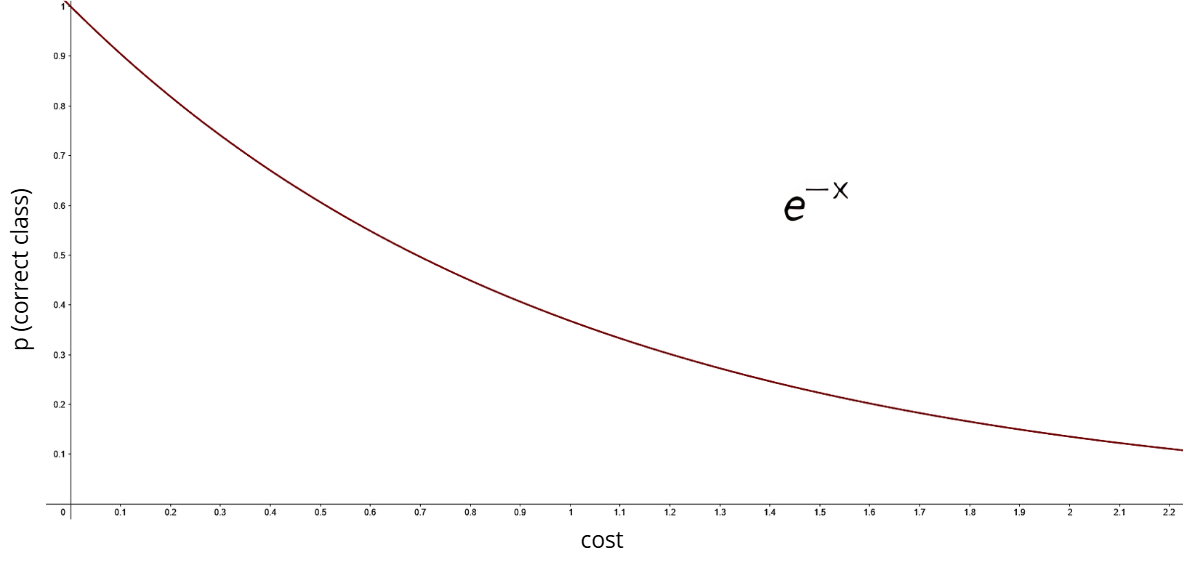

# **TEST NEURAL NETWORK**

**UNIT TESTS**

In [60]:
#Test weights' initialization

model= NeuralNetwork(0.1,2,[110,3],5)
model.initialize_weights()
print(model.weights)

[array([[0.03355754, 0.83096581],
       [0.7746822 , 0.4007888 ],
       [0.01269152, 0.8530603 ],
       [0.28871036, 0.93708575],
       [0.59645061, 0.32778998],
       [0.26494457, 0.42278453],
       [0.52485039, 0.22585889],
       [0.84025629, 0.93841913],
       [0.9531785 , 0.10937058],
       [0.02747418, 0.52722617],
       [0.95774387, 0.33777229],
       [0.08908764, 0.03479274],
       [0.55657125, 0.95727384],
       [0.9143992 , 0.77044953],
       [0.94609623, 0.53279847],
       [0.03905559, 0.53714867],
       [0.63171745, 0.07849671],
       [0.08172121, 0.91103918],
       [0.10601226, 0.68497552],
       [0.03859672, 0.61498937],
       [0.15160405, 0.8985146 ],
       [0.87403699, 0.85867175],
       [0.38228248, 0.97934501],
       [0.91295048, 0.21902892],
       [0.25544422, 0.60492535],
       [0.97580795, 0.74604687],
       [0.06077806, 0.11283593],
       [0.10731234, 0.59529286],
       [0.0855127 , 0.47166728],
       [0.39237033, 0.78550971],
       [0

In [61]:
#Test biases' initialization

model= NeuralNetwork(0.1,1,[2,2,1,2,1,1],5)
model.initialize_biases()
print(model.biases)

[array([[0.],
       [0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.],
       [0.]]), array([[0.]]), array([[0.]])]


In [72]:
#Test neuron' activations

model= NeuralNetwork(0.1,110,[110,3],5)
model.initialize_weights()
model.initialize_biases()
arr = np.zeros(110, dtype=int)
arr[10] = 1
arr[50] = 1
sample=np.array(arr)[:,None]
print(model.get_layer_activations(sample)[-1])

[[0.82715507]
 [0.01455103]
 [0.15829389]]


In [36]:
#Test neuron saving and loading

path = "/content/drive/MyDrive/my_neural_network"
model= NeuralNetwork(0.1,[3,1],1)
model.save(path)
print("Initial neural network")
print(model.weights)
print(model.biases)
print(model.learning_rate)

model2=NeuralNetwork.empty_neural_network()
model2.load(path+".npz")
print(" ")
print("neural network saved")
print(model2.weights)
print(model2.biases)
print(model2.learning_rate)

Initial neural network
[array([[0.43073806, 0.67468964, 0.69985606],
       [0.58030615, 0.44735097, 0.45073457],
       [0.52368004, 0.97764634, 0.75354133]]), array([[0.68437987, 0.22037957, 0.10779385]])]
[array([[0.],
       [0.],
       [0.]]), array([[0.]])]
0.1
 
neural network saved
[array([[0.43073806, 0.67468964, 0.69985606],
       [0.58030615, 0.44735097, 0.45073457],
       [0.52368004, 0.97764634, 0.75354133]]), array([[0.68437987, 0.22037957, 0.10779385]])]
[array([[0.],
       [0.],
       [0.]]), array([[0.]])]
0.1


# **EXPERIMENTS WITH NEURAL NETWORK**

**CHARGE SOCCER DATASET**

In [8]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
df=pd.read_csv('historical_european_soccer_matches.csv')

--2026-08-15 20:01:27--  https://raw.githubusercontent.com/LuisFelipeVelasco/ML_And_Generative_AI_Experiments/main/Sources/historical_european_soccer_matches.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2994531 (2.9M) [text/plain]
Saving to: ‘historical_european_soccer_matches.csv’

historical_european 100%[===================>]   2.86M  13.1MB/s    in 0.2s    

2026-08-15 20:01:29 (13.1 MB/s) - ‘historical_european_soccer_matches.csv’ saved [2994531/2994531]



**TRAIN NEURAL NETWORK**

100%|██████████| 3/3 [00:04<00:00,  1.34s/it]


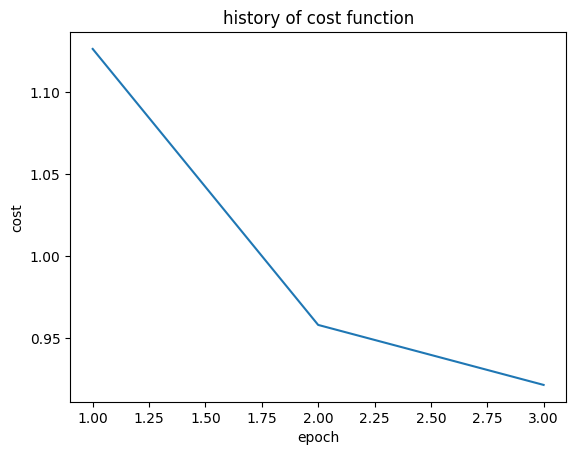

In [82]:
samples= df.iloc[:,:-3].values
labels= df.iloc[:,-3:].values
columns_count=samples.shape[1]
model= NeuralNetwork(0.001,columns_count,[110,3],3)
model.fit(samples,labels)
model.plot_cost_history()
path = "/content/drive/MyDrive/soccer_predictor.npz"
model.save(path)


**ID OF TEAMS**

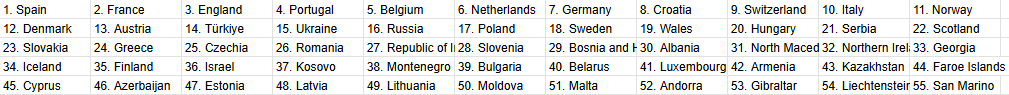

In [ ]:
def arg_max_prediction(predictions):
  if(np.max(predictions)==predictions[0][0]):
    print("The home team wins")
  elif(np.max(predictions)==predictions[1][0]):
    print("The away team wins")
  elif(np.max(predictions)==predictions[2][0]):
    print("The teams draw")



while True:
  id_home_team=int(input("type a home team by its id : ")) - 1
  id_away_team=int(input("type a away team by its id : ")) + 54
  sample=np.zeros(110)
  sample[id_home_team]=1
  sample[id_away_team]=1
  sample=sample[:,None]
  arg_max_prediction(model.predict(sample))

type a home team by its id : 1
type a away team by its id : 12
The home team wins
type a home team by its id : 3
type a away team by its id : 1
The away team wins
type a home team by its id : 1
type a away team by its id : 55
The home team wins
type a home team by its id : 1
type a away team by its id : 13
The home team wins
type a home team by its id : 7
type a away team by its id : 5
The home team wins
type a home team by its id : 5
type a away team by its id : 7
The away team wins
type a home team by its id : 1
type a away team by its id : 10
The home team wins
type a home team by its id : 10
type a away team by its id : 1
The teams draw
type a home team by its id : 1
type a away team by its id : 7
The teams draw
type a home team by its id : 7
type a away team by its id : 1
The away team wins
type a home team by its id : 7
type a away team by its id : 10
The teams draw
type a home team by its id : 10
type a away team by its id : 7
The teams draw
type a home team by its id : 4
type a